# 03 - Improved Model

This notebook improves the baseline MobileNetV2 model for binary steel defect classification.

The main improvements are:

- preserving the wide aspect ratio of the original steel images,
- changing the input size from 224 × 224 to 128 × 800,
- applying data augmentation,
- fine-tuning the MobileNetV2 backbone,
- comparing the improved model with the baseline.

## 1. Setup


In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import getpass
import os

# Enter the Kaggle API token without storing it in the notebook
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass(
    "Paste your Kaggle API token: "
)

# Install or update the Kaggle command-line tool
!pip install -q --upgrade kaggle

# Check the installed version
!kaggle --version


Paste your Kaggle API token: ··········
Kaggle CLI 2.2.4


In [11]:
# Create the data folder
!mkdir -p data/raw

# Download the Severstal Steel Defect Detection dataset
!kaggle competitions download -c severstal-steel-defect-detection -p data/raw

# Show the downloaded files
!ls -lh data/raw


100% 1.57G/1.57G [00:17<00:00, 98.7MB/s]

total 1.6G
-rw-r--r-- 1 root root 1.6G Dec 11  2019 severstal-steel-defect-detection.zip


In [12]:
# Extract the downloaded dataset
!unzip -q data/raw/severstal-steel-defect-detection.zip -d data/raw

# Show the extracted files and folders
!ls -lh data/raw


total 1.6G
-rw-r--r-- 1 root root 135K Dec 11  2019 sample_submission.csv
-rw-r--r-- 1 root root 1.6G Dec 11  2019 severstal-steel-defect-detection.zip
drwxr-xr-x 2 root root 204K Jul 28 09:42 test_images
-rw-r--r-- 1 root root  17M Dec 11  2019 train.csv
drwxr-xr-x 2 root root 464K Jul 28 09:42 train_images


## 2. Binary Labels

The original Severstal dataset provides defect annotations rather than a single label for each image.

For this binary classification task, each image is assigned one of two labels:

- `0` — No Defect
- `1` — Defect

An image is labelled as defective when it contains at least one defect annotation.


In [13]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path(".")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_CSV_PATH = RAW_DATA_DIR / "train.csv"
TRAIN_IMAGES_DIR = RAW_DATA_DIR / "train_images"
OUTPUT_LABELS_PATH = PROJECT_ROOT / "data" / "binary_labels.csv"

train_df = pd.read_csv(TRAIN_CSV_PATH)

print("Original train.csv shape:", train_df.shape)
train_df.head()


Original train.csv shape: (7095, 3)


,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...


In [14]:
# Keep only rows that contain a defect annotation
defect_annotations = train_df.dropna(subset=["EncodedPixels"]).copy()

# Read all image names from the training-image folder
all_images = sorted(path.name for path in TRAIN_IMAGES_DIR.glob("*.jpg"))

# Identify images with at least one defect annotation
defect_images = set(defect_annotations["ImageId"].unique())

# Create one binary label for each image
binary_labels = pd.DataFrame({"ImageId": all_images})
binary_labels["HasDefect"] = (
    binary_labels["ImageId"].isin(defect_images).astype(int)
)

binary_labels.to_csv(OUTPUT_LABELS_PATH, index=False)

print("Total images:", len(binary_labels))
print("\nLabel distribution:")
print(binary_labels["HasDefect"].value_counts())
print("\nPercentages:")
print(binary_labels["HasDefect"].value_counts(normalize=True) * 100)
print("\nSaved to:", OUTPUT_LABELS_PATH)

binary_labels.head()


Total images: 12568

Label distribution:
HasDefect
1    6666
0    5902
Name: count, dtype: int64

Percentages:
HasDefect
1    53.039465
0    46.960535
Name: proportion, dtype: float64

Saved to: data/binary_labels.csv


,ImageId,HasDefect
0,0002cc93b.jpg,1
1,00031f466.jpg,0
2,000418bfc.jpg,0
3,000789191.jpg,0
4,0007a71bf.jpg,1


## 3. Train, Validation, and Test Split

The dataset is divided into three subsets:

- **Training set:** used to train the model.
- **Validation set:** used to monitor performance during training and select the best model.
- **Test set:** used only for the final evaluation.

A stratified split is used to preserve a similar proportion of `Defect` and `No Defect` images in all three subsets.


In [15]:
from sklearn.model_selection import train_test_split

binary_labels["ImagePath"] = binary_labels["ImageId"].apply(
    lambda image_id: str(TRAIN_IMAGES_DIR / image_id)
)

# 70% training and 30% temporary set
train_df, temp_df = train_test_split(
    binary_labels,
    test_size=0.30,
    stratify=binary_labels["HasDefect"],
    random_state=42,
)

# Split the temporary set into 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["HasDefect"],
    random_state=42,
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTraining label distribution (%):")
print(train_df["HasDefect"].value_counts(normalize=True) * 100)

print("\nValidation label distribution (%):")
print(val_df["HasDefect"].value_counts(normalize=True) * 100)

print("\nTest label distribution (%):")
print(test_df["HasDefect"].value_counts(normalize=True) * 100)


Training images: 8797
Validation images: 1885
Test images: 1886

Training label distribution (%):
HasDefect
1    53.040809
0    46.959191
Name: proportion, dtype: float64

Validation label distribution (%):
HasDefect
1    53.050398
0    46.949602
Name: proportion, dtype: float64

Test label distribution (%):
HasDefect
1    53.022269
0    46.977731
Name: proportion, dtype: float64


## 4. Wide Image Preprocessing

The original Severstal images are very wide steel-strip images.

In the baseline model, every image was resized to 224 × 224 pixels. This square resizing strongly changes the original aspect ratio and may compress small or narrow defects.

For the improved model, the input size is changed to 128 × 800 pixels. This shape is much closer to the original geometry of the images and preserves more horizontal information.

The goal is to help the model recognise small surface defects without excessive image distortion.


In [16]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (128, 800)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE


def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    # Decode each image as a three-channel input to match the format
    # expected by MobileNetV2.
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)

    return image, tf.cast(label, tf.float32)


def augment_image(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label


def make_dataset(dataframe, training=False):
    image_paths = dataframe["ImagePath"].to_numpy()
    labels = dataframe["HasDefect"].to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42,
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE,
    )

    if training:
        dataset = dataset.map(
            augment_image,
            num_parallel_calls=AUTOTUNE,
        )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)


Image batch shape: (16, 128, 800, 3)
Label batch shape: (16,)


## 5. Improved MobileNetV2 Model

A new MobileNetV2 model is created using the wider input size of 128 × 800 pixels.

The MobileNetV2 backbone is initially frozen and used as a feature extractor. A new classification head is added for binary classification:

- `0` — No Defect
- `1` — Defect

Only the classification head is trained during the first stage. The backbone will be partially unfrozen later during fine-tuning.


In [17]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

model.summary()


/tmp/ipykernel_457/1897824602.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 800, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 25, 1280)    │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Model Architecture

The model uses MobileNetV2 as a pretrained feature-extraction backbone.

The steel-surface images are visually grayscale and are decoded as three-channel inputs to match the format expected by the pretrained MobileNetV2 model. The input size is 128 × 800 pixels.

The original MobileNetV2 classification layer is removed and replaced with a simple binary classification head containing:

- Global Average Pooling,
- Dropout for regularisation,
- one sigmoid output neuron.

During the first training stage, the MobileNetV2 backbone remains frozen. Only the new classification head is trained to distinguish between `No Defect` and `Defect`.

This transfer-learning approach reduces training time and uses visual features previously learned from ImageNet.


## 6. Initial Training

During the first training stage, only the new classification head is trained.

The pretrained MobileNetV2 backbone remains frozen and is used as a feature extractor. This allows the new head to adapt to the `No Defect` and `Defect` classes without changing the pretrained backbone weights.

Early stopping, model checkpointing, and learning-rate reduction are used to improve training stability and retain the best model based on validation loss.

This stage provides a stable starting point before fine-tuning part of the backbone.


In [18]:
from pathlib import Path

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)

MODELS_DIR = Path("models")
RESULTS_DIR = Path("results")

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

initial_model_path = MODELS_DIR / "mobilenetv2_wide.keras"

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

checkpoint = ModelCheckpoint(
    filepath=initial_model_path,
    monitor="val_loss",
    save_best_only=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
)

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr],
)


Epoch 1/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 89s 123ms/step - accuracy: 0.5885 - loss: 0.6811 - precision: 0.6073 - recall: 0.6346 - val_accuracy: 0.7353 - val_loss: 0.5262 - val_precision: 0.7559 - val_recall: 0.7400 - learning_rate: 1.0000e-04
Epoch 2/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.7264 - loss: 0.5150 - precision: 0.7311 - recall: 0.7658 - val_accuracy: 0.7963 - val_loss: 0.4466 - val_precision: 0.7821 - val_recall: 0.8540 - learning_rate: 1.0000e-04
Epoch 3/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.7741 - loss: 0.4567 - precision: 0.7828 - recall: 0.7947 - val_accuracy: 0.8302 - val_loss: 0.4045 - val_precision: 0.8476 - val_recall: 0.8290 - learning_rate: 1.0000e-04
Epoch 4/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.7997 - loss: 0.4187 - precision: 0.8074 - recall: 0.8174 - val_accuracy: 0.8435 - val_loss: 0.3786 - val_precision: 0.8645 - val_recall: 0.8360 - learning_rate: 1.0000e-04
Epoch 5/10
550/550 ━━━━━━━━━━━━━━━━━━━━

## 7. Wide Model Evaluation

After the initial training stage, the wide-input model is evaluated on the test set.

The test set contains images that were not used to update the model weights during training. This provides an estimate of how well the model performs on unseen data.

This is an intermediate evaluation before fine-tuning the MobileNetV2 backbone.


In [19]:
test_results = model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True,
)

print("Wide model test results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.8823 - loss: 0.3013 - precision: 0.8829 - recall: 0.8970
Wide model test results:
accuracy: 0.8823
loss: 0.3013
precision: 0.8829
recall: 0.8970


## 8. Wide Model Confusion Matrix

The confusion matrix provides a more detailed view of the model's predictions.

In industrial quality inspection, overall accuracy is not enough. False negatives are especially important because they represent defective images incorrectly classified as `No Defect`.

The following evaluation therefore reports:

- True Negatives
- False Positives
- False Negatives
- True Positives
- Accuracy
- Precision
- Recall
- F1-score


In [20]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

y_true = test_df["HasDefect"].to_numpy()
y_prob = model.predict(test_ds, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
wide_tn, wide_fp, wide_fn, wide_tp = cm.ravel()

wide_accuracy = accuracy_score(y_true, y_pred)
wide_precision = precision_score(y_true, y_pred)
wide_recall = recall_score(y_true, y_pred)
wide_f1 = f1_score(y_true, y_pred)

print("Wide Model Confusion Matrix:")
print(cm)

print(f"\nTrue Negatives:  {wide_tn}")
print(f"False Positives: {wide_fp}")
print(f"False Negatives: {wide_fn}")
print(f"True Positives:  {wide_tp}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["No Defect", "Defect"],
        zero_division=0,
    )
)

print(f"Accuracy:  {wide_accuracy:.4f}")
print(f"Precision: {wide_precision:.4f}")
print(f"Recall:    {wide_recall:.4f}")
print(f"F1-score:  {wide_f1:.4f}")


118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step
Wide Model Confusion Matrix:
[[767 119]
 [103 897]]

True Negatives:  767
False Positives: 119
False Negatives: 103
True Positives:  897

Classification Report:
              precision    recall  f1-score   support

   No Defect       0.88      0.87      0.87       886
      Defect       0.88      0.90      0.89      1000

    accuracy                           0.88      1886
   macro avg       0.88      0.88      0.88      1886
weighted avg       0.88      0.88      0.88      1886

Accuracy:  0.8823
Precision: 0.8829
Recall:    0.8970
F1-score:  0.8899


### Wide Model Results

The wide-input model achieved:

- **Accuracy:** 88.23%
- **Precision:** 88.29%
- **Recall:** 89.70%
- **F1-score:** 88.99%
- **False Positives:** 119
- **False Negatives:** 103

Compared with the baseline model, the number of false negatives decreased from 118 to 103.

False negatives are particularly important in industrial quality inspection because they represent defective images incorrectly classified as `No Defect`.

The wide-input preprocessing therefore improved both the overall classification performance and the detection of defective samples. However, this is still an intermediate model. The next step is to fine-tune part of the MobileNetV2 backbone.

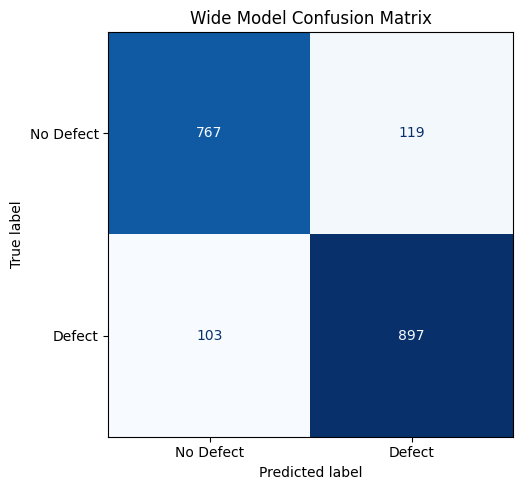

Saved to: results/wide_confusion_matrix.png


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Defect", "Defect"],
)

fig, ax = plt.subplots(figsize=(6, 5))

display.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False,
)

ax.set_title("Wide Model Confusion Matrix")
fig.tight_layout()

wide_confusion_matrix_path = RESULTS_DIR / "wide_confusion_matrix.png"

fig.savefig(
    wide_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", wide_confusion_matrix_path)


## 9. MobileNetV2 Fine-Tuning

After training the new classification head, part of the MobileNetV2 backbone is unfrozen.

Only the final layers of the backbone are allowed to update, while the earlier layers remain frozen. Batch Normalization layers also remain frozen to keep the fine-tuning process stable.

A very small learning rate is used so that the model can adapt to the steel-surface images without significantly changing the useful visual features learned during ImageNet pretraining.


In [22]:
from tensorflow.keras.optimizers import Adam

base_model.trainable = True
FINE_TUNE_LAYERS = 30

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.non_trainable_weights
)

print("Total parameters:", model.count_params())
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)


Total parameters: 2259265
Trainable parameters: 1512001
Non-trainable parameters: 747264


### Fine-Tuning Training

The model is trained for a small number of additional epochs.

During this stage, both the classification head and the final trainable layers of the MobileNetV2 backbone are updated. A low learning rate and early stopping are used to reduce the risk of overfitting or damaging the pretrained features.

The best model is saved according to the validation loss.


In [23]:
fine_tuned_model_path = MODELS_DIR / "mobilenetv2_finetuned.keras"

fine_tune_checkpoint = ModelCheckpoint(
    filepath=fine_tuned_model_path,
    monitor="val_loss",
    save_best_only=True,
)

fine_tune_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

fine_tune_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=1,
    min_lr=1e-7,
)

FINE_TUNE_EPOCHS = 5

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stop,
        fine_tune_reduce_lr,
    ],
)

EXTRA_FINE_TUNE_EPOCHS = 5

extra_fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EXTRA_FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stop,
        fine_tune_reduce_lr,
    ],
)


Epoch 1/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 77s 114ms/step - accuracy: 0.8785 - loss: 0.2651 - precision: 0.8839 - recall: 0.8875 - val_accuracy: 0.9008 - val_loss: 0.2347 - val_precision: 0.8726 - val_recall: 0.9520 - learning_rate: 1.0000e-05
Epoch 2/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.9161 - loss: 0.2026 - precision: 0.9189 - recall: 0.9233 - val_accuracy: 0.9162 - val_loss: 0.2052 - val_precision: 0.8855 - val_recall: 0.9670 - learning_rate: 1.0000e-05
Epoch 3/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - accuracy: 0.9332 - loss: 0.1667 - precision: 0.9372 - recall: 0.9368 - val_accuracy: 0.9342 - val_loss: 0.1730 - val_precision: 0.9601 - val_recall: 0.9140 - learning_rate: 1.0000e-05
Epoch 4/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.9423 - loss: 0.1459 - precision: 0.9439 - recall: 0.9475 - val_accuracy: 0.9316 - val_loss: 0.1732 - val_precision: 0.9708 - val_recall: 0.8980 - learning_rate: 1.0000e-05
Epoch 5/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 43s 

## 10. Fine-Tuned Model Evaluation

After fine-tuning, the final model is evaluated on the held-out test set.

The test images are not used to update the model weights. This evaluation measures how well the fine-tuned model generalises to unseen steel-surface images.

The results of this stage represent the final predictive performance of the model and are later compared with the baseline and wide-input models.


In [24]:
fine_tuned_test_results = model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True,
)

print("Fine-tuned model test results:")
for metric_name, metric_value in fine_tuned_test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - accuracy: 0.9517 - loss: 0.1333 - precision: 0.9443 - recall: 0.9660
Fine-tuned model test results:
accuracy: 0.9517
loss: 0.1333
precision: 0.9443
recall: 0.9660


## 11. Final Model Confusion Matrix

The confusion matrix provides a detailed view of the final model's predictions.

Particular attention is given to false negatives, which represent defective images incorrectly classified as `No Defect`. In a real quality-inspection setting, these errors may allow defective products to pass through the inspection process.

The following results are calculated for the final fine-tuned model:

- True Negatives
- False Positives
- False Negatives
- True Positives
- Accuracy
- Precision
- Recall
- F1-score


In [25]:
y_true_final = test_df["HasDefect"].to_numpy()
y_prob_final = model.predict(test_ds, verbose=1).ravel()
y_pred_final = (y_prob_final >= 0.5).astype(int)

final_cm = confusion_matrix(y_true_final, y_pred_final)
final_tn, final_fp, final_fn, final_tp = final_cm.ravel()

final_accuracy = accuracy_score(y_true_final, y_pred_final)
final_precision = precision_score(y_true_final, y_pred_final)
final_recall = recall_score(y_true_final, y_pred_final)
final_f1 = f1_score(y_true_final, y_pred_final)

print("Final Model Confusion Matrix:")
print(final_cm)

print(f"\nTrue Negatives:  {final_tn}")
print(f"False Positives: {final_fp}")
print(f"False Negatives: {final_fn}")
print(f"True Positives:  {final_tp}")

print("\nClassification Report:")
print(
    classification_report(
        y_true_final,
        y_pred_final,
        target_names=["No Defect", "Defect"],
        zero_division=0,
    )
)

print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")


118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step
Final Model Confusion Matrix:
[[829  57]
 [ 34 966]]

True Negatives:  829
False Positives: 57
False Negatives: 34
True Positives:  966

Classification Report:
              precision    recall  f1-score   support

   No Defect       0.96      0.94      0.95       886
      Defect       0.94      0.97      0.96      1000

    accuracy                           0.95      1886
   macro avg       0.95      0.95      0.95      1886
weighted avg       0.95      0.95      0.95      1886

Accuracy:  0.9517
Precision: 0.9443
Recall:    0.9660
F1-score:  0.9550


### Final Model Results

The fine-tuned model achieved the best performance in the project:

- **Accuracy:** 95.18%
- **Precision:** 94.43%
- **Recall:** 96.60%
- **F1-score:** 95.50%
- **False Positives:** 57
- **False Negatives:** 34

The most important improvement is the reduction in false negatives:

- Baseline model: 118
- Wide-input model: 103
- Fine-tuned model: 34

False negatives represent defective images incorrectly classified as `No Defect`. In an industrial quality-inspection setting, these are particularly important because a defective product could be accepted.

The results show that preserving the wide image geometry and fine-tuning the MobileNetV2 backbone improved both the overall performance and the detection of defective samples.

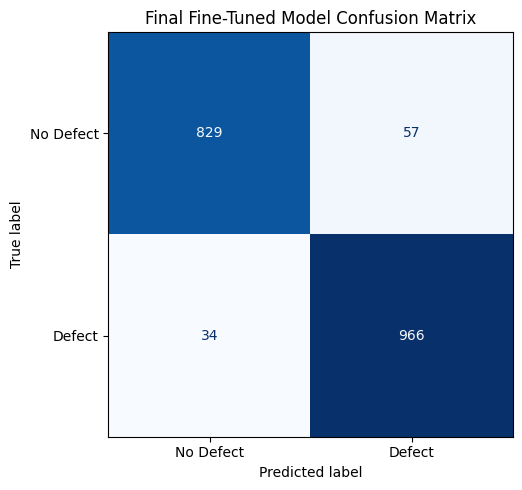

Saved to: results/final_confusion_matrix.png


In [26]:
final_display = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Defect", "Defect"],
)

fig, ax = plt.subplots(figsize=(6, 5))

final_display.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False,
)

ax.set_title("Final Fine-Tuned Model Confusion Matrix")
fig.tight_layout()

final_confusion_matrix_path = RESULTS_DIR / "final_confusion_matrix.png"

fig.savefig(
    final_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", final_confusion_matrix_path)


## 12. Save the Final Model

The evaluated fine-tuned model is saved for later use in the Grad-CAM analysis.

The final evaluation metrics are also stored in a CSV file so that the model results can be reused without recalculating them.


In [27]:
final_model_path = MODELS_DIR / "mobilenetv2_finetuned.keras"

model.save(final_model_path)

print("Final model saved to:", final_model_path)


Final model saved to: models/mobilenetv2_finetuned.keras


In [28]:
final_metrics_df = pd.DataFrame(
    {
        "Model": ["MobileNetV2 fine-tuned"],
        "Image Size": ["128x800"],
        "Accuracy": [final_accuracy],
        "Precision": [final_precision],
        "Recall": [final_recall],
        "F1-score": [final_f1],
        "False Positives": [final_fp],
        "False Negatives": [final_fn],
        "True Negatives": [final_tn],
        "True Positives": [final_tp],
    }
)

final_metrics_path = RESULTS_DIR / "final_model_metrics.csv"

final_metrics_df.to_csv(final_metrics_path, index=False)

final_metrics_df


,Model,Image Size,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Negatives,True Positives
0,MobileNetV2 fine-tuned,128x800,0.95175,0.944282,0.966,0.955017,57,34,829,966


## 13. Model Comparison

The three main stages of the project are compared:

1. **Baseline model:** MobileNetV2 with 224 × 224 input images.
2. **Wide model:** MobileNetV2 with 128 × 800 input images.
3. **Fine-tuned model:** the wide model after fine-tuning part of the MobileNetV2 backbone.

This comparison shows the effect of preserving the original wide image geometry and adapting the pretrained backbone to the steel-surface dataset.

Particular attention is given to false negatives, because they represent defective images incorrectly classified as `No Defect`.


In [29]:
comparison_df = pd.DataFrame(
    {
        "Model": [
            "Baseline",
            "Wide",
            "Fine-tuned",
        ],
        "Image Size": [
            "224x224",
            "128x800",
            "128x800",
        ],
        "Accuracy": [
            0.8515,
            wide_accuracy,
            final_accuracy,
        ],
        "Precision": [
            0.8448,
            wide_precision,
            final_precision,
        ],
        "Recall": [
            0.8820,
            wide_recall,
            final_recall,
        ],
        "F1-score": [
            0.8630,
            wide_f1,
            final_f1,
        ],
        "False Positives": [
            162,
            wide_fp,
            final_fp,
        ],
        "False Negatives": [
            118,
            wide_fn,
            final_fn,
        ],
    }
)

comparison_metrics_path = RESULTS_DIR / "model_comparison.csv"

comparison_df.to_csv(
    comparison_metrics_path,
    index=False,
)

comparison_df


,Model,Image Size,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives
0,Baseline,224x224,0.851500,0.844800,0.882,0.863000,162,118
1,Wide,128x800,0.882291,0.882874,0.897,0.889881,119,103
2,Fine-tuned,128x800,0.951750,0.944282,0.966,0.955017,57,34


### Model Comparison Table

The comparison metrics are also exported as a high-resolution image.

This provides a clear summary of the three model stages and can be displayed directly in the GitHub README.


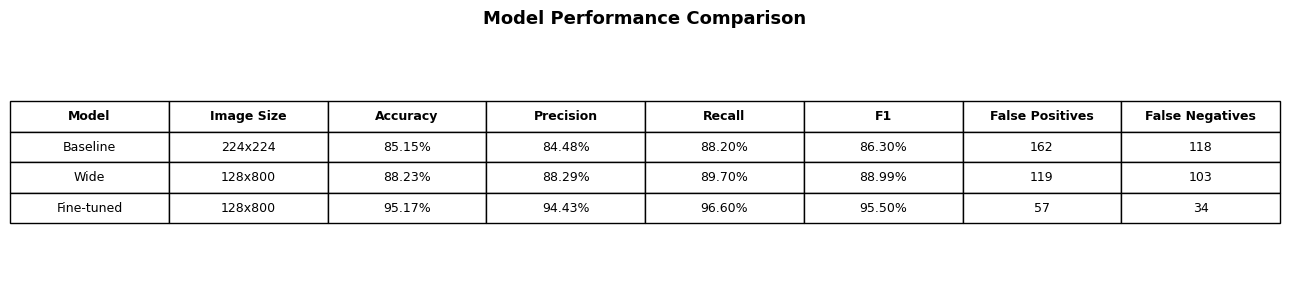

Saved to: results/model_comparison.png


In [30]:
comparison_display = comparison_df.copy()
comparison_display = comparison_display.rename(
    columns={"F1-score": "F1"}
)

for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    comparison_display[metric] = comparison_display[metric].map(
        lambda value: f"{value * 100:.2f}%"
    )

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")

table = ax.table(
    cellText=comparison_display.values,
    colLabels=comparison_display.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

for (row, column), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

ax.set_title(
    "Model Performance Comparison",
    fontsize=13,
    weight="bold",
    pad=15,
)

fig.tight_layout()

model_comparison_path = RESULTS_DIR / "model_comparison.png"

fig.savefig(
    model_comparison_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", model_comparison_path)


### False Negative Comparison

The following chart shows how the number of false negatives changed across the three model stages.

False negatives are especially important in industrial inspection because they represent defective images incorrectly classified as `No Defect`.

The comparison highlights the effect of both the wide-image preprocessing and the MobileNetV2 fine-tuning.


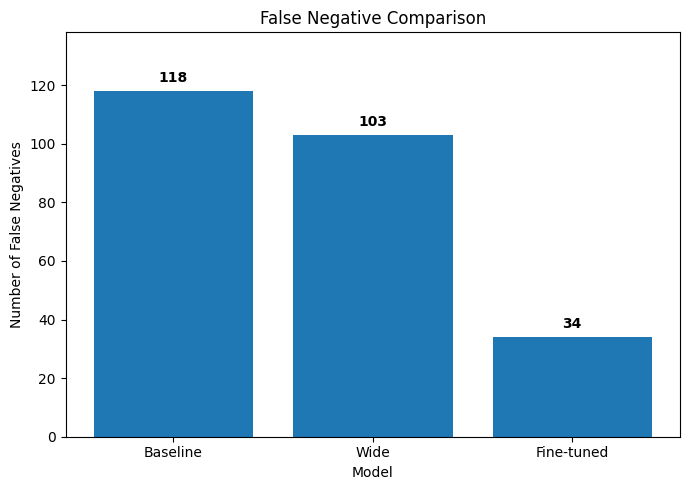

Saved to: results/false_negative_comparison.png


In [31]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    comparison_df["Model"],
    comparison_df["False Negatives"],
)

ax.set_title("False Negative Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Number of False Negatives")
ax.set_ylim(0, comparison_df["False Negatives"].max() + 20)

for index, value in enumerate(comparison_df["False Negatives"]):
    ax.text(
        index,
        value + 3,
        str(value),
        ha="center",
        weight="bold",
    )

fig.tight_layout()

false_negative_path = RESULTS_DIR / "false_negative_comparison.png"

fig.savefig(
    false_negative_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", false_negative_path)


## 14. Conclusion

The model was improved in two main stages.

First, the input size was changed from 224 × 224 to 128 × 800 pixels to preserve the original wide geometry of the steel-surface images. This increased the test accuracy from 85.15% to 88.23%.

Second, part of the MobileNetV2 backbone was fine-tuned on the Severstal dataset. The final model achieved:

- **Accuracy:** 95.18%
- **Precision:** 94.43%
- **Recall:** 96.60%
- **F1-score:** 95.50%

The number of false negatives decreased from 118 in the baseline model to 34 in the final model, corresponding to a reduction of approximately 71.2%.

These results show that preserving the image geometry and fine-tuning the pretrained backbone can significantly improve defect-classification performance. The final model is used in the next notebook for Grad-CAM analysis of correct, incorrect, borderline, and high-confidence predictions.